In [71]:
import datasets
import pandas
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import pandas as pd

In [9]:
from datasets import load_dataset
ds = load_dataset('flwrlabs/femnist')

# Federated MNIST Dataset

https://huggingface.co/datasets/flwrlabs/femnist

* image: grayscale of size (28,28) PIL Image
* writer_id: string, unique value for each writer
* hsf_id: string, corresponds to the way that the data was collected
* character: ClassLabel - ASCII Value

# Extract only letters a-j for each writer

In [938]:
train_dataset = ds['train']

In [940]:
only_a_j_dataset = train_dataset.filter(lambda x: 36 <= x['character'] <= 45)

In [844]:
columns = ['image', 'writer_id', 'hsf_id', 'character']
df = pd.DataFrame(columns = columns)

for i in tqdm(range(len(only_a_j_dataset)), desc = 'Processing Images'):
    img = only_a_j_dataset[i]['image']
    np_arr = np.array(img)
    img_arr = np_arr.reshape(784)

    curr = only_a_j_dataset[i]
    
    writer_id = curr['writer_id']
    hsf_id = curr['hsf_id']
    char = curr['character']

    new_item = {
        'image' : img_arr,
        'writer_id' : writer_id,
        'hsf_id' : hsf_id,
        'character' : char
    }

    df.loc[len(df)] = new_item

Processing Images: 100%|█████████████████| 84381/84381 [01:32<00:00, 914.71it/s]


# Saving Preprocessed DataFrame

In [847]:
df.to_pickle('dataframe.pkl')

In [73]:
import pandas as pd
df_loaded = pd.read_pickle('dataframe.pkl')

In [74]:
grouped_df = df_loaded.groupby('writer_id')

In [77]:
client_list = list(grouped_df.groups.keys())

In [79]:
import numpy as np
np.random.seed(42)

client_array = np.array(client_list)

def choose_clients(client_array, n):
    selected_clients = np.random.choice(client_array, size = n, replace = False)
    return selected_clients

client_subset = choose_clients(client_array, 200)

# Choose 200 random clients for sampling

In [82]:
df_filtered = df_loaded[df_loaded['writer_id'].isin(client_subset)]

# verify that only 200 groups remain
temp_df = df_filtered.groupby('writer_id')
print(len(temp_df.groups))

df_filtered.reset_index(drop = True, inplace = True)

200


In [84]:
def select_random_characters(group, num_classes):

    distinct_characters = group['character'].unique()
    num_classes_to_select = min(num_classes, len(distinct_characters))

    selected_characters = np.random.choice(distinct_characters, size = num_classes_to_select, replace = False)
    return group[group['character'].isin(selected_characters)]

num_classes = 10

df_filtered_selected = df_filtered.groupby('writer_id', group_keys = False).apply(select_random_characters, num_classes = num_classes)
df_filtered_selected.reset_index(drop = True, inplace = True)

/var/folders/1f/vmz43dnn7sd609gnr33rxxhr0000gn/T/ipykernel_87781/2818977227.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered_selected = df_filtered.groupby('writer_id', group_keys = False).apply(select_random_characters, num_classes = num_classes)


In [86]:
writer_classes_df = df_filtered_selected.groupby('writer_id')['character'].unique()
writer_classes_df = writer_classes_df.reset_index()
writer_classes_df.columns = ['writer_id', 'character_classes']

In [88]:
writer_classes_df = df_filtered_selected.groupby('writer_id')['character'].unique()
writer_classes_df = writer_classes_df.reset_index()

writer_classes_df.columns = ['writer_id', 'character_classes']

def count_items_in_classes(writer_id, character_classes):
    filtered_rows = df_filtered_selected[(df_filtered_selected['writer_id'] == writer_id) 
    & (df_filtered_selected['character'].isin(character_classes))]

    return len(filtered_rows)

writer_classes_df['num_items'] = writer_classes_df.apply(lambda row: count_items_in_classes(row['writer_id'], row['character_classes']), axis=1)

In [90]:
writer_classes_df = df_filtered_selected.groupby('writer_id')['character'].unique()
writer_classes_df = writer_classes_df.reset_index()

writer_classes_df.columns = ['writer_id', 'character_classes']

def count_items_in_classes(writer_id, character_classes, label):
    filtered_rows = df_filtered_selected[(df_filtered_selected['writer_id'] == writer_id) 
    & (df_filtered_selected['character'].isin([label]))]

    return len(filtered_rows)

letters = {
    36 : 'a', 
    37 : 'b',
    38 : 'c',
    39 : 'd',
    40 : 'e',
    41 : 'f',
    42 : 'g',
    43 : 'h',
    44 : 'i',
    45 : 'j',
}

for i in range(36, 46):
    writer_classes_df['num_items_' + letters[i]] = writer_classes_df.apply(lambda row: count_items_in_classes(row['writer_id'], row['character_classes'], i), axis=1)
writer_classes_df

,writer_id,character_classes,num_items_a,num_items_b,num_items_c,num_items_d,num_items_e,num_items_f,num_items_g,num_items_h,num_items_i,num_items_j
0,f0017_07,"[40, 36, 43, 44, 39, 42, 37, 41, 45, 38]",14,3,1,11,38,1,2,11,2,1
1,f0026_17,"[43, 42, 38, 41, 40, 45, 39, 44, 36, 37]",1,1,1,1,1,1,1,1,1,1
2,f0030_12,"[37, 43, 40, 36, 45, 39, 42, 44, 38]",4,4,1,6,12,0,2,4,1,1
3,f0032_27,"[36, 42, 40, 39, 37, 44, 45, 43, 38, 41]",10,3,1,10,13,1,1,4,1,1
4,f0051_42,"[39, 37, 44, 36, 45, 40, 43, 42, 38]",13,4,1,8,14,0,4,11,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...
195,f4054_12,"[43, 38, 36, 37, 40, 39]",2,1,2,1,1,0,0,1,0,0
196,f4064_46,"[37, 38, 42, 39, 41, 43, 40]",0,1,1,1,1,1,1,1,0,0
197,f4068_21,"[37, 45, 43, 40, 41, 38, 36, 39, 42]",1,1,1,1,1,1,1,1,0,1
198,f4088_26,"[40, 39, 37, 43, 44, 36, 41]",1,1,0,1,2,1,0,1,1,0


In [91]:
writer_id_list = []
for w in df_filtered_selected['writer_id'].unique():
    writer_id_list.append(w)

def create_U(writer_id_list):

    U = dict()

    for w_id in writer_id_list:
    
        matches = df_filtered_selected[df_filtered_selected['writer_id'] == w_id]

        U_i = []

        for i in range(len(matches['image'])):
            U_i.append(matches['image'].iloc[i])

        U_i = np.array(U_i)
        U[w_id] = U_i

    return U

def create_v(writer_id_list, binary):

    v = dict()

    for w_id in writer_id_list:

        matches = df_filtered_selected[df_filtered_selected['writer_id'] == w_id]

        v_i = []

        for i in range(len(matches['image'])):

            if binary:
                label = 1 if matches['character'].iloc[i] == 36 else -1
            else:
                label = matches['character'].iloc[i]

            v_i.append(label)

        v_i = np.array(v_i)

        v[w_id] = v_i

    return v

U = create_U(writer_id_list)
v = create_v(writer_id_list, binary = True)

In [92]:
def df_U_i(writer_id):
    df_U_i = pd.DataFrame(U[writer_id])
    return df_U_i

def df_v_i(writer_id):
    df_v_i = pd.DataFrame(v[writer_id])
    return df_v_i

In [94]:
n = 784
N_total = 5413
x_global = np.zeros((n,1))
x_global

mu = 10 ** -2

In [98]:
from numpy import linalg as LA
from math import log, exp

In [100]:
def obj_f(U, v, x):
    vU = U * v[:, np.newaxis][0]
    vUx = -np.dot(vU.T, x)
    N = U.shape[1]
    return (mu * LA.norm(x) ** 2) + sum([vUx[i,0] if vUx[i,0] > 709 else log(1 + exp(vUx[i,0])) for i in range(N)])/N

In [102]:
df_filtered['label'] = df_filtered['character'].apply(lambda x: 1 if x == 36 else -1)

/var/folders/1f/vmz43dnn7sd609gnr33rxxhr0000gn/T/ipykernel_87781/1666767293.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['label'] = df_filtered['character'].apply(lambda x: 1 if x == 36 else -1)


In [104]:
image_arrays = np.array(df_filtered['image'].tolist())
U_matrix = image_arrays.T

In [106]:
v_vector = np.array([df_filtered['label'].tolist()])

In [108]:
client_list = list(U.keys())

In [110]:
def stoch_grad_F(x, client_id, i): 
    U_c = U[client_id].T
    v_c = np.array([v[client_id]])
    vU = U_c * v_c[:, np.newaxis][0]
    return (mu * x) + (-vU[:, [i]] / (1 + np.exp(min(709, np.dot(vU[:, [i]].T, x)[0, 0]))))

In [112]:
eta = 1
def SGD(x_0, client_id, k_max, stepsize, epoch_length, minibatch_size):
    x_epoch_vals = dict()
    x_epoch_vals[0] = x_0
    x_next = x_0
    N_specific = len(U[client_id])
    for k in range(k_max):
        minibatch_indices = list(np.random.randint(N_specific, size = minibatch_size))
        mini_batch_stoch_grad = sum(stoch_grad_F(x_next, client_id, i) for i in minibatch_indices)/minibatch_size
        x_next = x_next - stepsize * (mini_batch_stoch_grad + eta * (x_0 - x_next))

        if ((k + 1) % epoch_length) == 0:
            x_epoch_vals[(k+1)//epoch_length] = x_next

    return x_epoch_vals

In [114]:
n_epoch = 10
minibatch_size = 1
stepsize_choices = [10 ** -7, 10 ** -6, 10 ** -5, 10 ** -4]
stepsize = 10 ** -8

In [116]:
m = 200 # number of devices

In [118]:
import numpy as np
import matplotlib.pyplot as plt

R = 40

# One run of federated averaging
def federated_averaging_run():
    x_global_list = [x_global]
    x_epoch_vals_by_client = {c: [] for c in client_list}
    local_objective_values = {c: [] for c in client_list}

    for r in range(R):
        curr_global = x_global_list[-1]
        next_global = np.zeros((784, 1))

        for c in client_list:
            N_curr = len(U[c])

            SGD_result = SGD(curr_global, c, 5, stepsize, 1, minibatch_size)
            x_epoch_vals_by_client[c].extend(list(SGD_result.values()))
            curr_local_sol = x_epoch_vals_by_client[c][-1]

            next_global += curr_local_sol * N_curr

        x_global_list.append(next_global / N_total)

    for c in client_list:
        for x_val in x_epoch_vals_by_client[c]:
            obj_val = obj_f(U[c].T, np.array([v[c]]), x_val)
            local_objective_values[c].append(obj_val)

    return local_objective_values, x_global_list

np.random.seed(42)

# Run federated averaging with 10 different seeds
runs = {}
global_sols = {}
for i in tqdm(range(10)):
    np.random.seed(42 + i)
    runs[i], global_sols[i] = federated_averaging_run()

100%|███████████████████████████████████████████| 10/10 [00:57<00:00,  5.77s/it]


In [120]:
client_end_avg = dict()

for client in client_list:
    avg = 0
    for r in range(len(runs)):
        avg += runs[r][client][-1]
    avg /= len(runs)
    client_end_avg[client] = avg

In [122]:
sorted_items = sorted(client_end_avg.items(), key=lambda x: x[1])
best_clients = [key for key, value in sorted_items[:2]]
worst_clients = [key for key, value in sorted_items[-2:]]
print(best_clients)
print(worst_clients)

['f3577_03', 'f3257_17']
['f2514_50', 'f1368_03']


In [124]:
num_runs = len(runs)

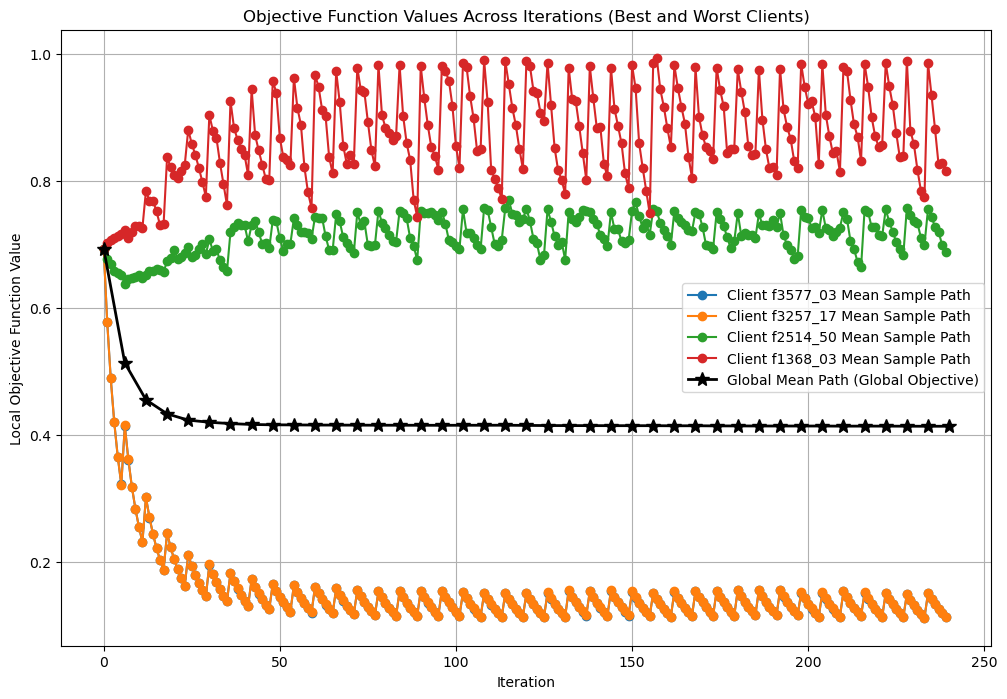

In [126]:
def local_obj_sample_path_means(client):
    mean_local_obj_values = []
    num_iter = len(runs[0][client])


    for i in range(num_iter):
        curr_mean = 0
        for r in range(num_runs):
            curr_mean += runs[r][client][i]
        mean_local_obj_values.append(curr_mean / num_runs)

    return mean_local_obj_values

def plot_all_clients_y_vals(client_keys):
    plt.figure(figsize=(12, 8))
    
    for client in client_keys:
        y_vals = local_obj_sample_path_means(client)
        x_vals = range(len(y_vals))
        plt.plot(x_vals, y_vals, marker='o', label=f'Client {client} Mean Sample Path')

    global_loss_function_vals = []
    num_sols = len(global_sols[0])
    for i in range(num_sols):
        curr_mean = 0
        for j in range(num_runs):
            curr_mean += obj_f(U_matrix, v_vector, global_sols[j][i])
        curr_mean /= num_runs
        global_loss_function_vals.append(curr_mean)

    num_iter = len(runs[0][client])

    x_vals = []
    for i in range(0, num_iter+1, num_iter // (num_sols) + 1):
        x_vals.append(i)

    plt.plot(x_vals, global_loss_function_vals, marker = '*', markersize = 10, linewidth = 2, color = 'black', label = 'Global Mean Path (Global Objective)')
    
    plt.xlabel('Iteration')
    plt.ylabel('Local Objective Function Value')
    plt.title('Objective Function Values Across Iterations (Best and Worst Clients)')
    plt.grid(True)
    plt.legend()
    plt.show()

best_and_worst_clients = best_clients + worst_clients
plot_all_clients_y_vals(best_and_worst_clients)

In [127]:
global_sols[0][-1].shape

(784, 1)

In [128]:
average_final_sol_vector = np.zeros((n,1))
for i in range(num_runs): # for each run
    curr_sol_vector = global_sols[i][-1] # from current run
    average_final_sol_vector += curr_sol_vector # aggregate across runs
average_final_sol_vector /= num_runs
average_final_sol_vector

array([[-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74406167e-06],
       [-9.74399813e-06],
       [-9.74406167e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74412520e-06],
       [-9.74406681e-06],
       [-9.74389895e-06],
       [-9.74376545e-06],
       [-9.7

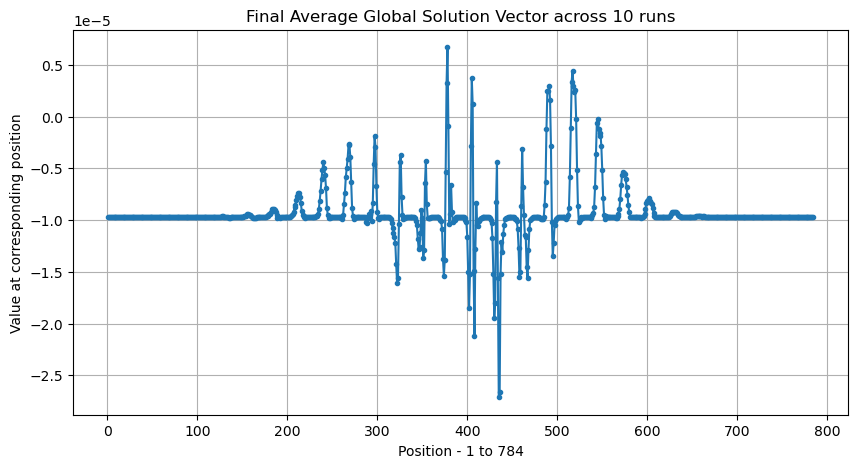

In [129]:
y_values = average_final_sol_vector.flatten()
x_values = np.arange(1, 785)

plt.figure(figsize=(10, 5))
plt.plot(x_values, y_values, marker='o', linestyle='-', markersize=3)
plt.xlabel("Position - 1 to 784")
plt.ylabel("Value at corresponding position")
plt.title("Final Average Global Solution Vector across 10 runs")
plt.grid(True)
plt.show()

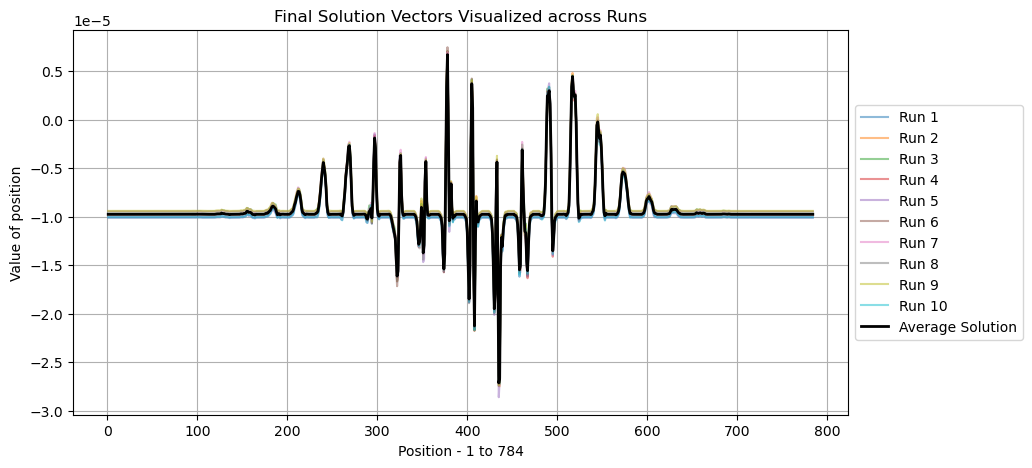

In [130]:
average_final_sol_vector = np.zeros((n, 1))

plt.figure(figsize=(10, 5))
x_values = np.arange(1, 785)

for i in range(num_runs):
    curr_sol_vector = global_sols[i][-1]  # Last solution from the current run
    average_final_sol_vector += curr_sol_vector  # Aggregate across runs
    plt.plot(x_values, curr_sol_vector.flatten(), alpha=0.5, linestyle='-', markersize=2, label=f'Run {i+1}')

average_final_sol_vector /= num_runs

plt.plot(x_values, average_final_sol_vector.flatten(), color='black', linewidth=2, label='Average Solution')

plt.xlabel("Position - 1 to 784")
plt.ylabel("Value of position")
plt.title("Final Solution Vectors Visualized across Runs")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

# Show the plot
plt.show()


In [131]:
# fedprox + sparsity